# ML-KEM-512 `cmov` Capture on Husky

Este notebook esta ajustado al firmware real de este directorio.

Puntos importantes verificados en el repo:
- El firmware registra `k`, `h`, `l` y `t` con `simpleserial_addcmd(...)` en [simpleserial-ml-kem-512.c](/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/simpleserial-ml-kem-512.c#L422).
- El `makefile` de este objetivo incluye `Makefile.simpleserial`, cuyo valor por defecto es `SS_VER_1_1`, no `SS_VER_2_1`.
- Si el firmware fue compilado sin pasar `SS_VER=SS_VER_2_1`, Python debe hablar SimpleSerial v1, es decir `cw.target(scope)`.
- El trigger en firmware rodea solo `PQCLEAN_MLKEM512_CLEAN_cmov(...)`.

Limitacion importante:
- Como repites el mismo `sk` y el mismo `ct`, este notebook no hace un CPA clasico entre trazas.
- En su lugar deja una rutina automatica de exploracion para `cmov` basada en ventanas por byte del bucle de 32 bytes.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re
import time

import chipwhisperer as cw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm.notebook import trange

WORKDIR = Path.cwd()
PLATFORM = 'CWHUSKY'
SS_VER = 'SS_VER_1_1'
FIRMWARE_C = Path('/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/simpleserial-ml-kem-512.c')
FIRMWARE_HEX = Path('/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512') / f'simpleserial-ml-kem-512-{PLATFORM}.hex'
OUTPUT_DIR = WORKDIR / 'cmov_capture_output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

COMMAND = 'k'
DUMMY_PAYLOAD = bytearray([0xEE] * 16)
N_TRACES = 5000
ADC_SAMPLES = 3000
ADC_OFFSET = 0
GAIN_DB = 18
CAPTURE_TIMEOUT = 5
PREVIEW_COUNT = 20

LED1 = bytes([16])
LED2 = bytes([15])
LED3 = bytes([14])

CMOV_BYTES = 32
DEFAULT_MODEL_NAME = 'delta_ss'

print(f'Firmware source: {FIRMWARE_C}')
print(f'Firmware hex: {FIRMWARE_HEX}')
print(f'SimpleSerial expected: {SS_VER}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'Traces planned: {N_TRACES}')
print(f'ADC samples: {ADC_SAMPLES}')

Firmware source: /opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/simpleserial-ml-kem-512.c
Firmware hex: /opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/simpleserial-ml-kem-512-CWHUSKY.hex
SimpleSerial expected: SS_VER_1_1
Output directory: /opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/cmov_capture_output
Traces planned: 5000
ADC samples: 3000


In [2]:
def parse_c_byte_array(source_text: str, name: str) -> np.ndarray:
    pattern = rf'uint8_t\s+{re.escape(name)}\[\d+\]\s*=\s*\{{(.*?)\}};'
    match = re.search(pattern, source_text, re.S)
    if match is None:
        raise ValueError(f'Array {name!r} not found in {FIRMWARE_C}')

    body = match.group(1)
    values = []
    for token in body.replace('\n', ' ').split(','):
        token = token.strip()
        if not token:
            continue
        values.append(int(token, 16))
    return np.array(values, dtype=np.uint8)


def hw_u8(values: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=np.uint8)
    return np.unpackbits(values[:, None], axis=1).sum(axis=1)


def bit_column(values: np.ndarray, bit_index: int) -> np.ndarray:
    values = np.asarray(values, dtype=np.uint8)
    return ((values >> bit_index) & 1).astype(np.uint8)


source_text = FIRMWARE_C.read_text()
pk = parse_c_byte_array(source_text, 'pk')
sk = parse_c_byte_array(source_text, 'sk')
ct = parse_c_byte_array(source_text, 'ct')
ss = parse_c_byte_array(source_text, 'ss')
ss2 = parse_c_byte_array(source_text, 'ss2')

reference_vectors = {
    'pk': pk,
    'sk': sk,
    'ct': ct,
    'ss': ss,
    'ss2': ss2,
    'delta_ss': np.bitwise_xor(ss, ss2),
    'sk_first32': sk[:CMOV_BYTES],
    'ct_first32': ct[:CMOV_BYTES],
}

for name, values in reference_vectors.items():
    print(f'{name:10s} len={len(values):4d} first8={[hex(int(v)) for v in values[:8]]}')

reference_df = pd.DataFrame({
    'byte_index': np.arange(CMOV_BYTES),
    'ss': ss[:CMOV_BYTES],
    'ss2': ss2[:CMOV_BYTES],
    'delta_ss': np.bitwise_xor(ss[:CMOV_BYTES], ss2[:CMOV_BYTES]),
    'sk_first32': sk[:CMOV_BYTES],
    'ct_first32': ct[:CMOV_BYTES],
})
reference_df['ss_hw'] = hw_u8(reference_df['ss'].to_numpy(dtype=np.uint8))
reference_df['ss2_hw'] = hw_u8(reference_df['ss2'].to_numpy(dtype=np.uint8))
reference_df['delta_hw'] = hw_u8(reference_df['delta_ss'].to_numpy(dtype=np.uint8))
reference_df['sk_hw'] = hw_u8(reference_df['sk_first32'].to_numpy(dtype=np.uint8))
reference_df.head()

pk         len= 800 first8=['0x48', '0x81', '0x58', '0x85', '0xb5', '0x66', '0x2d', '0xd4']
sk         len=1632 first8=['0x78', '0xd3', '0x8c', '0x15', '0xd4', '0xca', '0x32', '0xa3']
ct         len= 768 first8=['0x46', '0x3f', '0xc0', '0x99', '0x19', '0x47', '0x9c', '0xd6']
ss         len=  32 first8=['0x17', '0xe1', '0x59', '0x71', '0x5', '0x4c', '0xd3', '0xac']
ss2        len=  32 first8=['0xfb', '0x73', '0x85', '0xbf', '0x22', '0x39', '0xcb', '0x99']
delta_ss   len=  32 first8=['0xec', '0x92', '0xdc', '0xce', '0x27', '0x75', '0x18', '0x35']
sk_first32 len=  32 first8=['0x78', '0xd3', '0x8c', '0x15', '0xd4', '0xca', '0x32', '0xa3']
ct_first32 len=  32 first8=['0x46', '0x3f', '0xc0', '0x99', '0x19', '0x47', '0x9c', '0xd6']


,byte_index,ss,ss2,delta_ss,sk_first32,ct_first32,ss_hw,ss2_hw,delta_hw,sk_hw
0,0,23,251,236,120,70,4,7,5,4
1,1,225,115,146,211,63,4,5,3,5
2,2,89,133,220,140,192,4,3,5,3
3,3,113,191,206,21,153,4,7,5,3
4,4,5,34,39,212,25,2,2,4,4


## Conexion y configuracion

La configuracion arranca conservadora para una primera corrida sobre Husky:
- `ADC_SAMPLES = 3000`
- `ADC_OFFSET = 0`
- `GAIN_DB = 18`

Si el trigger queda bien centrado y ves demasiado margen libre, reduce `ADC_SAMPLES`.

In [3]:
try:
    if not scope.connectStatus:
        scope.con()
except NameError:
    scope = cw.scope()

try:
    target = cw.target(scope)
except IOError:
    print('INFO: Caught exception on reconnecting to target - attempting to reconnect to scope first.')
    print('INFO: This is a work-around when USB has died without Python knowing. Ignore errors above this line.')
    scope = cw.scope()
    target = cw.target(scope)

print('INFO: Found ChipWhisperer')

if 'STM' in PLATFORM or PLATFORM == 'CWLITEARM' or PLATFORM == 'CWNANO':
    prog = cw.programmers.STM32FProgrammer
elif PLATFORM == 'CW303' or PLATFORM == 'CWLITEXMEGA':
    prog = cw.programmers.XMEGAProgrammer
elif 'neorv32' in PLATFORM.lower():
    prog = cw.programmers.NEORV32Programmer
elif PLATFORM == 'CW308_SAM4S' or PLATFORM == 'CWHUSKY':
    prog = cw.programmers.SAM4SProgrammer
else:
    prog = None

time.sleep(0.05)
scope.default_setup()

if PLATFORM == 'CW308_SAM4S' or PLATFORM == 'CWHUSKY':
    scope.io.target_pwr = 0
    time.sleep(0.2)
    scope.io.target_pwr = 1
    time.sleep(0.2)

def reset_target(scope):
    if PLATFORM == 'CW303' or PLATFORM == 'CWLITEXMEGA':
        scope.io.pdic = 'low'
        time.sleep(0.1)
        scope.io.pdic = 'high_z'
        time.sleep(0.1)
    elif 'neorv32' in PLATFORM.lower():
        raise IOError('Default iCE40 neorv32 build does not have external reset - reprogram device to reset')
    elif PLATFORM == 'CW308_SAM4S' or PLATFORM == 'CWHUSKY':
        scope.io.nrst = 'low'
        time.sleep(0.25)
        scope.io.nrst = 'high_z'
        time.sleep(0.25)
    else:
        scope.io.nrst = 'low'
        time.sleep(0.05)
        scope.io.nrst = 'high_z'
        time.sleep(0.05)

scope.gain.db = GAIN_DB
scope.adc.offset = ADC_OFFSET
scope.adc.samples = ADC_SAMPLES
scope.adc.timeout = CAPTURE_TIMEOUT

cw.program_target(scope, prog, str(FIRMWARE_HEX))
reset_target(scope)
target.flush()

print(f'SS_VER notebook = {SS_VER}')
print(f'gain.db         = {scope.gain.db}')
print(f'adc.offset      = {scope.adc.offset}')
print(f'adc.samples     = {scope.adc.samples}')
print(f'adc.timeout     = {scope.adc.timeout}')
print(f'firmware hex    = {FIRMWARE_HEX}')

INFO: Found ChipWhisperer
scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 327828                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.clock.adc_rate                     changed from 0.0                       to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen             

Prueba 1: LED3 por SimpleSerial
Si LED3 no cambio, no sigas con captura: el problema es comunicacion/programacion.
Prueba 2: una sola captura con k


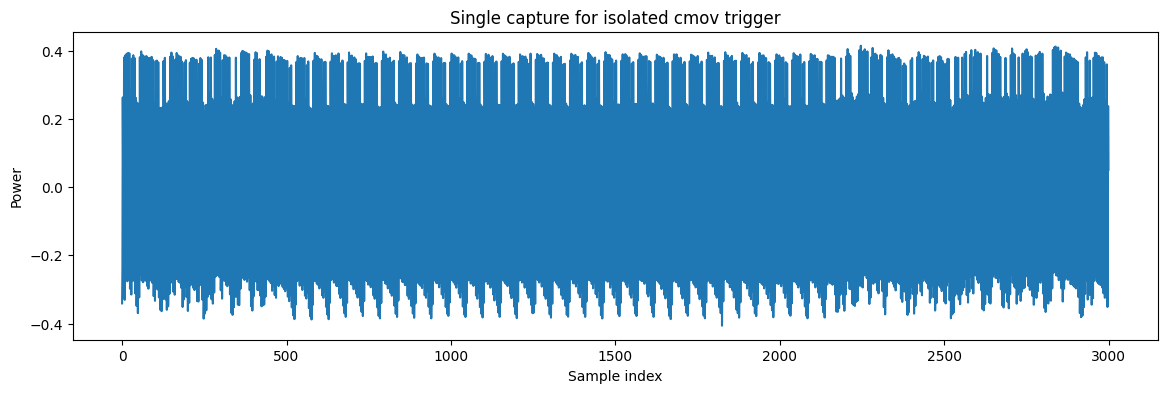

Prueba 3: preview corto


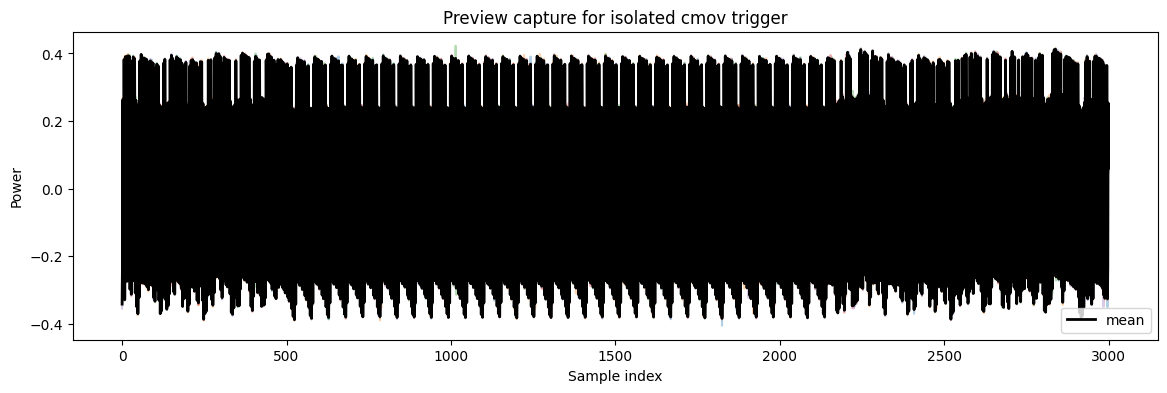

In [4]:
def send_led_command(command: str, led_value: bytes) -> None:
    target.simpleserial_write(command, led_value)
    time.sleep(0.15)

print('Prueba 1: LED3 por SimpleSerial')
send_led_command('l', LED3)
send_led_command('h', LED3)
send_led_command('l', LED3)
print('Si LED3 no cambio, no sigas con captura: el problema es comunicacion/programacion.')

key = bytearray([0xEE] * 16)

def capture_once(retries: int = 3) -> np.ndarray:
    last_status = None
    for _ in range(retries):
        target.flush()
        scope.arm()
        target.simpleserial_write('k', key)
        ret = scope.capture()
        last_status = ret
        if ret == 0:
            return np.asarray(scope.get_last_trace(), dtype=np.float32)
        reset_target(scope)
        target.flush()
        time.sleep(0.1)
    raise RuntimeError(f'Target timed out during capture after {retries} attempts; last status={last_status}')

print('Prueba 2: una sola captura con k')
single_trace = capture_once()
plt.figure(figsize=(14, 4))
plt.plot(single_trace)
plt.title('Single capture for isolated cmov trigger')
plt.xlabel('Sample index')
plt.ylabel('Power')
plt.show()

print('Prueba 3: preview corto')
preview_traces = [single_trace]
for _ in range(PREVIEW_COUNT - 1):
    preview_traces.append(capture_once())

preview_traces = np.vstack(preview_traces)
preview_mean = preview_traces.mean(axis=0)

plt.figure(figsize=(14, 4))
for trace in preview_traces[:5]:
    plt.plot(trace, alpha=0.35)
plt.plot(preview_mean, linewidth=2.0, color='black', label='mean')
plt.title('Preview capture for isolated cmov trigger')
plt.xlabel('Sample index')
plt.ylabel('Power')
plt.legend()
plt.show()

## Captura principal

No se espera respuesta por UART. Cada traza se obtiene solo por trigger.

In [5]:
traces = []
capture_rows = []
start_time = time.time()

for trace_index in trange(N_TRACES, desc='Capturing cmov traces'):
    try:
        trace = capture_once()
    except RuntimeError as exc:
        capture_rows.append({
            'trace_index': trace_index,
            'status': 'timeout',
            'samples': 0,
            'error': str(exc),
        })
        continue

    traces.append(trace)
    capture_rows.append({
        'trace_index': trace_index,
        'status': 'ok',
        'samples': len(trace),
        'error': '',
    })

elapsed = time.time() - start_time
capture_log = pd.DataFrame(capture_rows)
good_traces = int((capture_log['status'] == 'ok').sum())
print(f'Captured {good_traces}/{N_TRACES} good traces in {elapsed:.1f}s')

if good_traces == 0:
    raise RuntimeError('No valid traces captured')

trace_matrix = np.vstack(traces)
trace_matrix.shape

Capturing cmov traces:   0%|          | 0/5000 [00:00<?, ?it/s]

Captured 5000/5000 good traces in 338.2s


(5000, 3000)

In [6]:
run_tag = time.strftime('%Y%m%d-%H%M%S')
npz_path = OUTPUT_DIR / f'cmov_traces_{run_tag}.npz'
csv_log_path = OUTPUT_DIR / f'cmov_capture_log_{run_tag}.csv'
csv_mean_path = OUTPUT_DIR / f'cmov_mean_trace_{run_tag}.csv'
json_meta_path = OUTPUT_DIR / f'cmov_metadata_{run_tag}.json'

mean_trace = trace_matrix.mean(axis=0)
std_trace = trace_matrix.std(axis=0)

np.savez_compressed(
    npz_path,
    traces=trace_matrix,
    mean_trace=mean_trace,
    std_trace=std_trace,
    ss=ss,
    ss2=ss2,
    ct=ct,
    sk=sk,
    delta_ss=np.bitwise_xor(ss, ss2),
)

capture_log.to_csv(csv_log_path, index=False)
pd.DataFrame({
    'sample_index': np.arange(trace_matrix.shape[1]),
    'mean_trace': mean_trace,
    'std_trace': std_trace,
}).to_csv(csv_mean_path, index=False)

json_meta_path.write_text(json.dumps({
    'command': COMMAND,
    'dummy_payload_hex': DUMMY_PAYLOAD.hex(),
    'n_traces_requested': N_TRACES,
    'n_traces_captured': int(trace_matrix.shape[0]),
    'adc_samples': int(trace_matrix.shape[1]),
    'adc_offset': ADC_OFFSET,
    'gain_db': GAIN_DB,
    'reference_vectors': {
        'ss_hex': ss.tobytes().hex(),
        'ss2_hex': ss2.tobytes().hex(),
        'delta_ss_hex': np.bitwise_xor(ss, ss2).tobytes().hex(),
        'ct_first32_hex': ct[:CMOV_BYTES].tobytes().hex(),
        'sk_first32_hex': sk[:CMOV_BYTES].tobytes().hex(),
    },
}, indent=2))

print(npz_path)
print(csv_log_path)
print(csv_mean_path)
print(json_meta_path)

/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/cmov_capture_output/cmov_traces_20260418-184923.npz
/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/cmov_capture_output/cmov_capture_log_20260418-184923.csv
/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/cmov_capture_output/cmov_mean_trace_20260418-184923.csv
/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/cmov_capture_output/cmov_metadata_20260418-184923.json


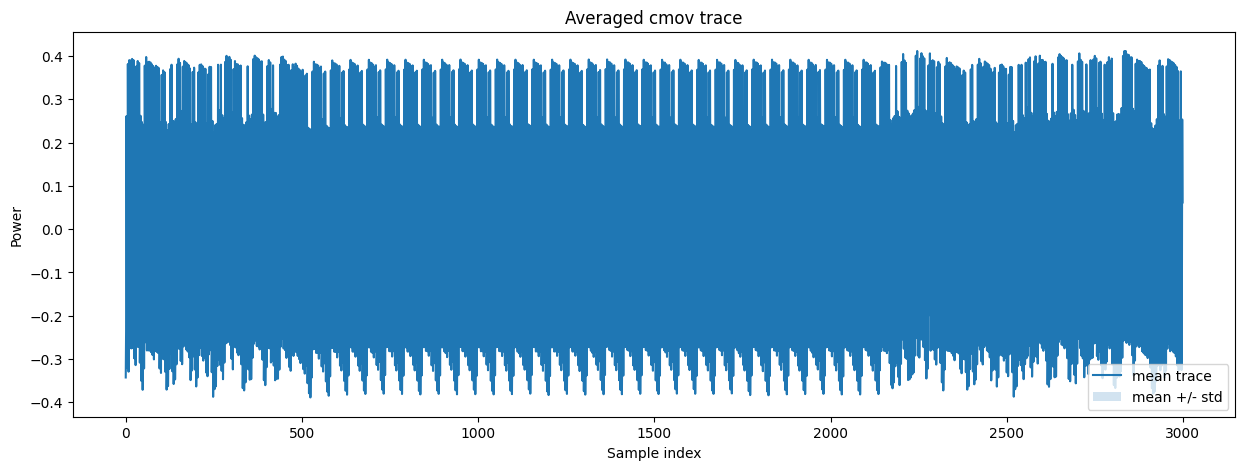

In [7]:
plt.figure(figsize=(15, 5))
plt.plot(mean_trace, label='mean trace')
plt.fill_between(
    np.arange(len(mean_trace)),
    mean_trace - std_trace,
    mean_trace + std_trace,
    alpha=0.2,
    label='mean +/- std',
)
plt.title('Averaged cmov trace')
plt.xlabel('Sample index')
plt.ylabel('Power')
plt.legend()
plt.show()

## Rutina automatica por ventanas de byte

Esta parte no usa variacion entre trazas, porque el caso actual repite siempre el mismo material.

La idea es:
- promediar muchas trazas para limpiar ruido
- dividir la region capturada en 32 ventanas, una por iteracion esperada del bucle `cmov`
- extraer una caracteristica simple por ventana
- correlacionar esa caracteristica contra bytes, bits o HW de un vector conocido

Modelo recomendado para `cmov`:
- `delta_ss = ss XOR ss2`

Ese modelo no reemplaza un ataque formal, pero es util para localizar fuga real en el bucle.

In [8]:
def build_window_features(trace: np.ndarray, byte_count: int = CMOV_BYTES) -> pd.DataFrame:
    trace = np.asarray(trace, dtype=np.float64)
    window_edges = np.linspace(0, len(trace), byte_count + 1, dtype=int)
    rows = []
    for byte_index in range(byte_count):
        start = window_edges[byte_index]
        stop = window_edges[byte_index + 1]
        window = trace[start:stop]
        rows.append({
            'byte_index': byte_index,
            'start': start,
            'stop': stop,
            'mean': float(window.mean()),
            'abs_mean': float(np.mean(np.abs(window))),
            'energy': float(np.sum(window ** 2)),
            'ptp': float(np.ptp(window)),
        })
    return pd.DataFrame(rows)


def correlation_score(feature: np.ndarray, model: np.ndarray) -> float:
    feature = np.asarray(feature, dtype=np.float64)
    model = np.asarray(model, dtype=np.float64)
    if feature.std() == 0 or model.std() == 0:
        return 0.0
    return float(np.corrcoef(feature, model)[0, 1])


def build_model_table(model_name: str = DEFAULT_MODEL_NAME) -> pd.DataFrame:
    model_bytes = np.asarray(reference_vectors[model_name][:CMOV_BYTES], dtype=np.uint8)
    table = pd.DataFrame({
        'byte_index': np.arange(CMOV_BYTES),
        'value': model_bytes,
        'hw': hw_u8(model_bytes),
    })
    for bit_index in range(8):
        table[f'bit_{bit_index}'] = bit_column(model_bytes, bit_index)
    return table


def rank_models(mean_trace: np.ndarray, model_name: str = DEFAULT_MODEL_NAME) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    feature_table = build_window_features(mean_trace, CMOV_BYTES)
    model_table = build_model_table(model_name)
    merged = feature_table.merge(model_table, on='byte_index', how='inner')

    feature_columns = ['mean', 'abs_mean', 'energy', 'ptp']
    model_columns = ['value', 'hw'] + [f'bit_{bit_index}' for bit_index in range(8)]
    rows = []
    for feature_column in feature_columns:
        feature_vector = merged[feature_column].to_numpy()
        for model_column in model_columns:
            score = correlation_score(feature_vector, merged[model_column].to_numpy())
            rows.append({
                'feature': feature_column,
                'model': model_column,
                'corr': score,
                'abs_corr': abs(score),
            })
    ranking = pd.DataFrame(rows).sort_values('abs_corr', ascending=False).reset_index(drop=True)
    return merged, ranking, model_table

In [9]:
MODEL_NAME = DEFAULT_MODEL_NAME
window_table, ranking_table, model_table = rank_models(mean_trace, MODEL_NAME)

display(ranking_table.head(12))
display(window_table.head())

,feature,model,corr,abs_corr
0,abs_mean,bit_3,0.458715,0.458715
1,abs_mean,hw,0.336699,0.336699
2,abs_mean,bit_5,0.328406,0.328406
3,energy,bit_0,-0.308461,0.308461
4,energy,bit_4,0.249694,0.249694
5,energy,bit_3,0.249521,0.249521
6,abs_mean,bit_2,0.248627,0.248627
7,ptp,bit_2,0.241217,0.241217
8,energy,bit_6,-0.222601,0.222601
9,ptp,hw,0.212163,0.212163


,byte_index,start,stop,mean,abs_mean,energy,ptp,value,hw,bit_0,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7
0,0,0,93,0.024311,0.213928,5.810537,0.768658,236,5,0,0,1,1,0,1,1,1
1,1,93,187,0.006047,0.214818,5.784319,0.764212,146,3,0,1,0,0,1,0,0,1
2,2,187,281,-0.009993,0.216747,5.813305,0.767780,220,5,0,0,1,1,1,0,1,1
3,3,281,375,0.019386,0.213628,5.846823,0.773183,206,5,0,1,1,1,0,0,1,1
4,4,375,468,0.013494,0.213941,5.675413,0.758916,39,4,1,1,1,0,0,1,0,0


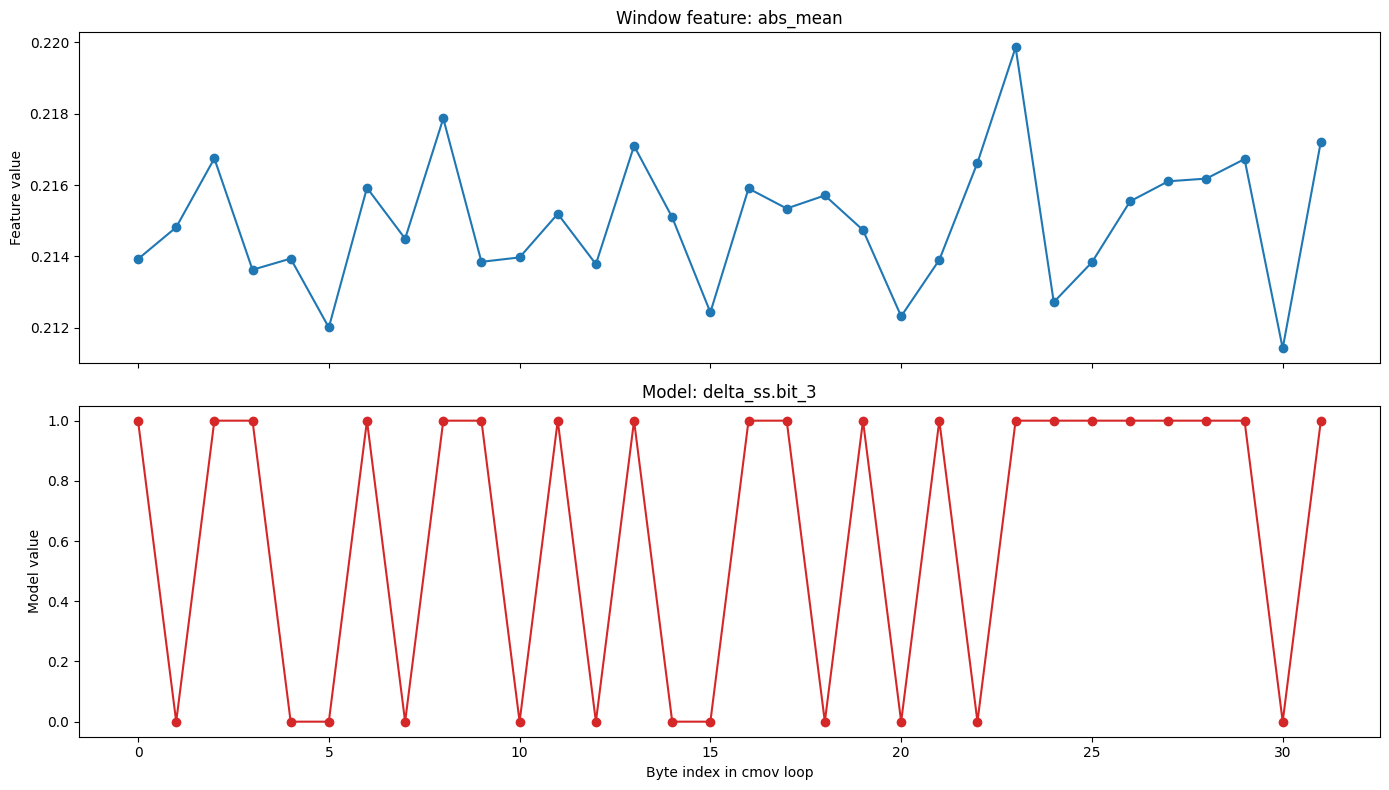

/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/cmov_capture_output/cmov_window_ranking_20260418-184923.csv
/opt/tools/chipwhisperer/firmware/mcu/simpleserial-ml-kem-512/cmov_capture_output/cmov_window_features_20260418-184923.csv


In [10]:
best_feature = ranking_table.iloc[0]['feature']
best_model = ranking_table.iloc[0]['model']

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(window_table['byte_index'], window_table[best_feature], marker='o')
axes[0].set_title(f'Window feature: {best_feature}')
axes[0].set_ylabel('Feature value')

axes[1].plot(window_table['byte_index'], window_table[best_model], marker='o', color='tab:red')
axes[1].set_title(f'Model: {MODEL_NAME}.{best_model}')
axes[1].set_xlabel('Byte index in cmov loop')
axes[1].set_ylabel('Model value')
plt.tight_layout()
plt.show()

ranking_csv_path = OUTPUT_DIR / f'cmov_window_ranking_{run_tag}.csv'
window_csv_path = OUTPUT_DIR / f'cmov_window_features_{run_tag}.csv'
ranking_table.to_csv(ranking_csv_path, index=False)
window_table.to_csv(window_csv_path, index=False)
print(ranking_csv_path)
print(window_csv_path)

## Pruebas rapidas de modelos alternos

Cambia `MODEL_NAME` por uno de estos valores y vuelve a ejecutar las dos celdas anteriores:
- `delta_ss`
- `ss`
- `ss2`
- `sk_first32`
- `ct_first32`

In [11]:
scope.dis()
target.dis()
print('Scope and target disconnected')

Scope and target disconnected
